# HSNM MONTE CARLO ANALYSIS

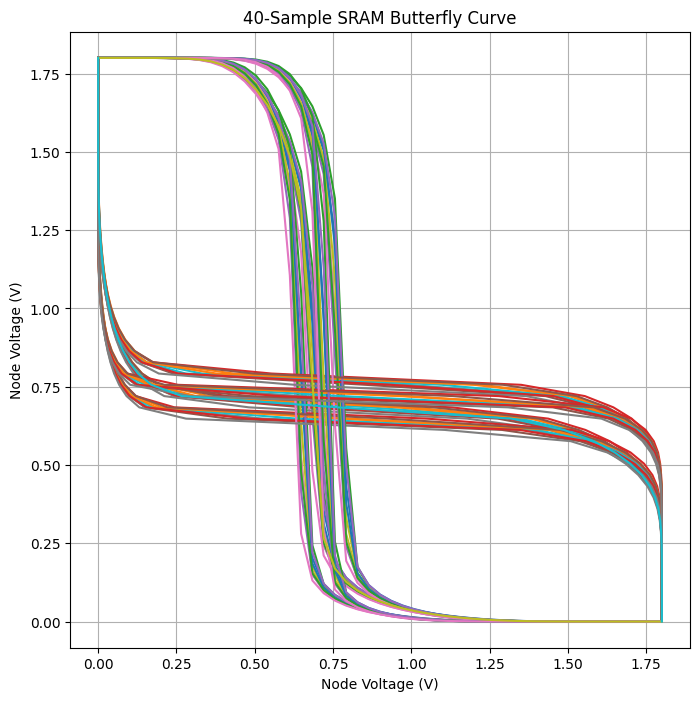

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("HSNM_MONTE.csv")

plt.figure(figsize=(8,8))

# Plot all Monte Carlo samples
for i in range(0, len(df.columns), 2):

    vin = df.iloc[:, i]
    vout = df.iloc[:, i+1]

    # First inverter
    plt.plot(vin, vout)

    # Mirrored inverter
    plt.plot(vout, vin)

plt.xlabel("Node Voltage (V)")
plt.ylabel("Node Voltage (V)")
plt.title("40-Sample SRAM Butterfly Curve")
plt.grid(True)
plt.axis('equal')

plt.show()

# RSNM MONTE CARLO ANALYSIS

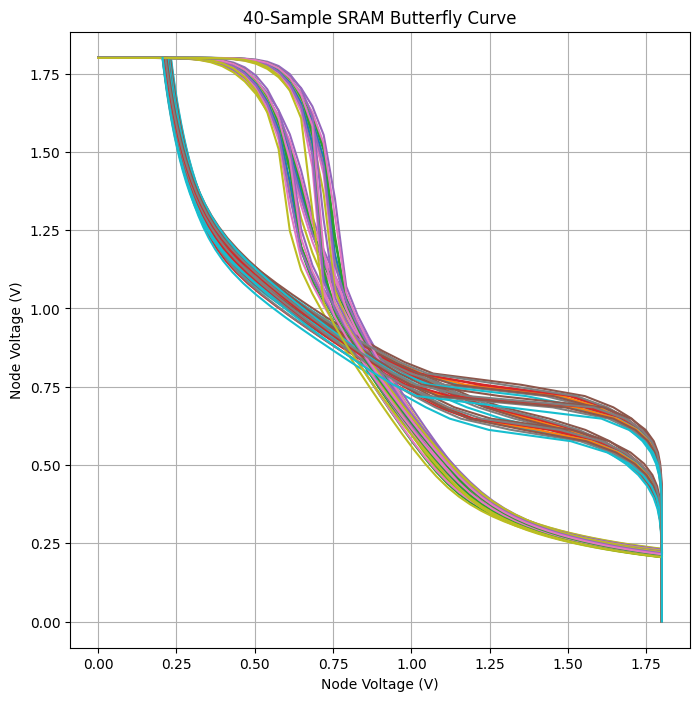

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("RSNM_MONTE.csv")

plt.figure(figsize=(8,8))

# Plot all Monte Carlo samples
for i in range(0, len(df.columns), 2):

    vin = df.iloc[:, i]
    vout = df.iloc[:, i+1]

    # First inverter
    plt.plot(vin, vout)

    # Mirrored inverter
    plt.plot(vout, vin)

plt.xlabel("Node Voltage (V)")
plt.ylabel("Node Voltage (V)")
plt.title("40-Sample SRAM Butterfly Curve")
plt.grid(True)
plt.axis('equal')

plt.show()

# WSNM MONTE CARLO ANALYSIS

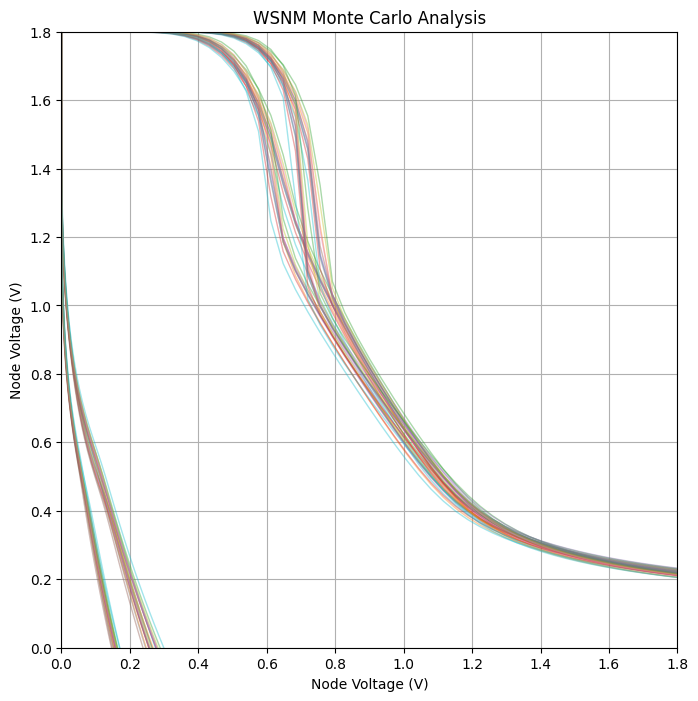

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("WSNM_MONTE(Sheet1).csv")

plt.figure(figsize=(8, 8))

# ---------- Curve 1: VIN vs Q ----------
# Plotted normally: X = VIN, Y = Q
for col in df.columns:
    if col.startswith('/Q') and not col.startswith('/QB') and col.endswith('X'):
        vin = pd.to_numeric(df[col], errors='coerce')
        q   = pd.to_numeric(df[col[:-1] + 'Y'], errors='coerce')

        valid = ~(vin.isna() | q.isna())
        # Plot VIN on X-axis, Q on Y-axis
        plt.plot(vin[valid], q[valid], linewidth=1, alpha=0.4)

# ---------- Curve 2: QB vs VIN (Swapped to VIN vs QB) ----------
# To get the matching WSNM characteristic, we swap axes: X = QB, Y = VIN
for col in df.columns:
    if col.startswith('/QB') and col.endswith('X'):
        vin = pd.to_numeric(df[col], errors='coerce')
        qb  = pd.to_numeric(df[col[:-1] + 'Y'], errors='coerce')

        valid = ~(vin.isna() | qb.isna())
        # Swap axes: Plot QB on X-axis, VIN on Y-axis
        plt.plot(qb[valid], vin[valid], linewidth=1, alpha=0.4)

plt.xlabel('Node Voltage (V)')
plt.ylabel('Node Voltage (V)')
plt.title('WSNM Monte Carlo Analysis')

plt.xlim(0, 1.8)
plt.ylim(0, 1.8)

plt.grid(True)
plt.gca().set_aspect('equal')

plt.show()